# **MÓDULO 27 - Projeto de Doenças Cardiovasculares - Regressão Logística**


Nessa projeto foi construído um modelo que nos ajuda a prever doenças cardiovasculares. A base usada contém dados reais, organizados da seguinte maneira:
- age - idade dos pacientes
- gender - genero (2 mulheres) (1 homens)
- height - altura dos pacientes
- weight - peso dos pacientes
- gluc - glicose
- smoke - fumante (1) não fumante (0)
- alco - consume alcool (1) não consome (0)
- active - realiza atividades fisicas (1) não realiza (0)
- cardio_disease - tem doença cardio (1) não tem (0) - Variável target

In [117]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, roc_auc_score, classification_report
import plotly.express as px

# 1) Tratamento dos dados/Pré-processamento


In [118]:
base = pd.read_csv("CARDIO_BASE.csv", delimiter=';')

O primeiro passo foi corrigir os tipos das variáveis. OCmo evidenciado a seguir, a única variável com tipo inadequado era a "weight", de peso. Para corrigir, ofi necessário trocar todas as "," por ".", para que os valores ficassem de acordo ocm a convenção americana. Como alguns valores tem números decimais, o tipo foi alterado para float, não int, como as outras. 

In [119]:
base.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             10000 non-null  int64 
 1   gender          10000 non-null  int64 
 2   height          10000 non-null  int64 
 3   weight          10000 non-null  object
 4   cholesterol     10000 non-null  int64 
 5   gluc            10000 non-null  int64 
 6   smoke           10000 non-null  int64 
 7   alco            10000 non-null  int64 
 8   active          10000 non-null  int64 
 9   cardio_disease  10000 non-null  int64 
dtypes: int64(9), object(1)
memory usage: 781.4+ KB


In [120]:
base["weight"] = base["weight"].str.replace(",", ".").astype(float)


In [121]:
base.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             10000 non-null  int64  
 1   gender          10000 non-null  int64  
 2   height          10000 non-null  int64  
 3   weight          10000 non-null  float64
 4   cholesterol     10000 non-null  int64  
 5   gluc            10000 non-null  int64  
 6   smoke           10000 non-null  int64  
 7   alco            10000 non-null  int64  
 8   active          10000 non-null  int64  
 9   cardio_disease  10000 non-null  int64  
dtypes: float64(1), int64(9)
memory usage: 781.4 KB


## Dados faltantes
Por vezes, nem todos os campos das bases tem dados. Por isso , é essencial averigar a presençaa de vaores errados, nulos ou de espaços em branco. Primeiro, a partir das informações da info() acima, é sabido que a base não tem números nulos. Abaixo eu conferi novamente se havia algum dado nulo, apenas por precaução. Após, verificou-se se algum valor era não numérico, supondo que, segundo indicado no iníco do projeto, todos os valores deveriam ser numéricos, ou boleanos. 

In [122]:
print(base.isnull().sum())

age               0
gender            0
height            0
weight            0
cholesterol       0
gluc              0
smoke             0
alco              0
active            0
cardio_disease    0
dtype: int64


In [123]:
for column in base.columns:
    for value in base[column]:
        if column != "weight" and base[column].dtype != 'int64':
            print(f"{column} contém valor não numérico.") 
        elif column == "weight" and base[column].dtype != 'float64':
            print(f"{column} contém valor não numérico.")


## Outliers
O primeiro passo para a identificação de outliers é a análise do retornjo da função describe(). A média, valor máximo e mínimo de todas as variáveis discretas apresentaram o comportamente esperado. 
O valor máximo de height, altura, é 250 cm, ou seja , 2,5m, e do peso, 200Kg, propvavelmente são outliers. Pela avaliação do boxplot desses campos, evidenciandoevidenciou-se o  comportamento de outlier. 

In [124]:
base.describe()

,age,gender,height,weight,cholesterol,gluc,smoke,alco,active,cardio_disease
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,53.288300,1.345400,164.308200,74.303710,1.365000,1.222200,0.089000,0.053700,0.797200,0.503100
std,6.796234,0.475522,8.178796,14.566353,0.677658,0.565561,0.284758,0.225436,0.402105,0.500015
min,30.000000,1.000000,70.000000,30.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,1.000000,159.000000,65.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
50%,54.000000,1.000000,165.000000,72.000000,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000
75%,58.000000,2.000000,170.000000,82.000000,2.000000,1.000000,0.000000,0.000000,1.000000,1.000000
max,65.000000,2.000000,250.000000,200.000000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000


In [125]:
fig = px.box(base, y='weight', title='Box Plot do Peso', labels={'weight': 'Peso (kg)'})
fig.show()

In [126]:
fig = px.box(base, y='height', title='Box Plot da Altura', labels={'height': 'Altura (cm)'})
fig.show()

### Correção dos Outliers

Nessa etapa, é crítica a análise de quais valores serão considerados outliers. Isso pode ser feito analisando o conjunto de dados acima e abaixo de 75% e 25%, respectivamente. A análise desses valores indicam se os dados que se destacam são pontos fora da curva, ou apenas valores altos.
Identificado os outliers, há duas formas de corrigí-los: exclusão ou substituição. 
Para verificar a possibildade de exclusão, foi avaliado o percentual que os dados outliers representam em relação à base total.



#### Altura

Os valores mais altos da Altura estão concentrados na média 175 cm, valor próximo ao 75% identificado anteriormente. O desvio padrão é pequeno, o que reforça a tese de que estão concentrados na média. Ao considerar o que previamente se conhece sobre a distribuição de altura da população em geral, optou-se por não excluir todos os valores acima de 75%, afinal, são alturas razoáveis, possíveis. Foi excluído apenas o valor 250cm, por ele ser um valor irreal, e estar isolado muito a cima dos demais.

Para os valores menores do que 25%, o comportamento foi similar. Contudo, a análise é mais delicada, pois não foi explicitado se o modelo deve considerar crianças, ou apenas adultos. Considerou-se que os dados tratam apenas de adultos pois, como mostra o gráfico abaixo, o intervalo de idades inicia em 30 anos. Inclusive, o histograma mostra que os registros entre 30 e 35 anos são muito menores do que o restante, possibilitanto que eles sejam descartados.

In [127]:
px.histogram(base, x='age', title='Histograma de Idade',  color_discrete_sequence=['indianred'] ,labels={'age': 'Idade (anos)'}, barmode="group", histnorm="percent", nbins=60).show()

In [134]:
base = base[base["age"] > 35]
px.histogram(base, x='age', title='Histograma de Idade Corrigido',  color_discrete_sequence=['indianred'] ,labels={'age': 'Idade (anos)'}, barmode="group", histnorm="percent", nbins=60).show()

Por esses motivos, e por que os dados se concentram em valores de alturas típicas de pessoas adultas, optou-se por excluir os valores abaixo de um limite especificado, que não prejudique a base. Essa escolha torna o modelo menos eficiente para pessoas com nanismo, especialmente os casos mais graves, de maneira que um banco de dados mais robusto e voltado para essa população pode contribuir para o enriquecimento do modelo.

Para determinar esse limite de corte, escolheu-se um valor que não elimine mais do que 10% do banco de dados.

In [129]:
base[["height"]].describe()

,height
count,9999.000000
mean,164.307131
std,8.178506
min,70.000000
25%,159.000000
50%,165.000000
75%,170.000000
max,250.000000


In [130]:
outlier = base["height"][base["height"] > 200]
100*len(outlier) / len(base["height"])


0.010001000100010001

In [131]:
outlier = base["height"][base["height"] < 140]
100*len(outlier) / len(base["height"])

0.21002100210021002

In [132]:
base = base[(base["height"] <200)]
base = base[base["height"] >= 140]
base.describe()

,age,gender,height,weight,cholesterol,gluc,smoke,alco,active,cardio_disease
count,9977.000000,9977.000000,9977.000000,9977.000000,9977.000000,9977.000000,9977.000000,9977.000000,9977.000000,9977.000000
mean,53.296883,1.345194,164.394808,74.297294,1.365340,1.222612,0.089005,0.053824,0.796933,0.503458
std,6.788170,0.475455,7.821689,14.507180,0.677965,0.566063,0.284765,0.225681,0.402302,0.500013
min,39.000000,1.000000,140.000000,37.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,1.000000,159.000000,65.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
50%,54.000000,1.000000,165.000000,72.000000,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000
75%,58.000000,2.000000,170.000000,82.000000,2.000000,1.000000,0.000000,0.000000,1.000000,1.000000
max,65.000000,2.000000,198.000000,200.000000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000


### Peso

Os principais outliers são valores superiores, que representam pessoas com muito peso. Por um lado, como a obesidade está fortemente relacionada a doenças cardiácas, a excluão dos dados pode prejudicar o modelo. Por outro, como são poucos dados, vão contribuir negativamente para a predição do modelo para essa populção.

Foi decidido excluir os outliers e indicar que o modelo tem essa limitação, tanto para pesos maiores do que 120Kg, quanto para menores do que 40Kg. No futuro, o modelo deve ser aprimorado com uma banco de dados mais diverso. excluir num dado. No futuro, será necessário investir em treinamento com um banco de dados mais diverso. 

In [153]:
base = base[(base["weight"]<120)]
base= base[base["weight"]>40]

In [154]:
fig = px.histogram(base, x='weight', nbins=15, color_discrete_sequence=['indianred'] ,labels={'wheight': 'Peso (Kg)'}, barmode="group", histnorm="percent", title='Histograma')
fig.update_layout(title='Distribuição do Peso Corrigida',
                  xaxis_title='Peso',
                  yaxis_title='Contagem'
                 )
fig.show()

# 2) Análise Bivariada

Para escolher quais variáveis analisar em relação às doenças cardiácas, a matriz de correlação foi analisada. Abaixo, segue um recorte das correlações apenas para `cardio_disease`. As três variáveis com maior correlação são: idade, colesterol e peso. Além de serem os maiores valores absolutos, são maiores do que o dobro do 4° lugar. Por esses motivos, escolheu-se essas três variáveis para a análise.


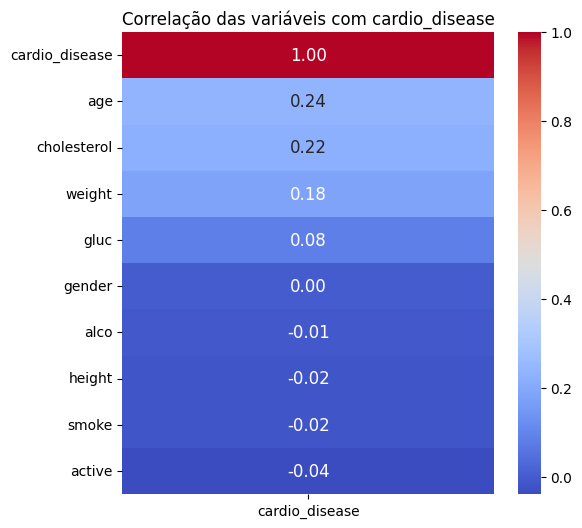

In [155]:
correlation_matrix = base.corr()
column = 'cardio_disease'
correlation_cardio = correlation_matrix[[column]].sort_values(by=column, ascending=False)

plt.figure(figsize=(6, 6))
sns.heatmap(correlation_cardio, annot=True, cmap='coolwarm', fmt=".2f", annot_kws={"size": 12})
plt.title(f'Correlação das variáveis com {column}')
plt.show()

### Análise 1: Relação entre Doenças Cardíacas e Idade



O gráfico abaixo mostra a dsitribuição da idade por doença cardíaca. As barras valores em azul acumulam a contagem de pessoas sem doenças cardíacas, enquanto as barras em vermelho acumulam a contagem de pessoas com doençaos cardíacas. Até aproximadamente 55 anos, os dados de pessoas com doenças cardiácas são menores do que os sem doenças. A partir dessa idade, a relação entre eles é invertidada e a população com doenças cardíacas aumenta proporcionalmente a idade.

Essas reflexões indicam, tal qual sua correlação, que idade é um importante fator na previsão de doenças cardíacas.

In [156]:
 
grouped = base.groupby(['age', 'cardio_disease']).size().reset_index(name='count')
grouped['percent'] = grouped.groupby('age')['count'].transform(lambda x: x / x.sum() * 100)
fig = px.histogram(grouped, x='age', y='percent', color='cardio_disease', barmode='stack',
             labels={'percent': 'Percentual (%)', 'age': 'Faixa de Idade', 
                     'cardio_disease': 'Doença Cardíaca'},
             title='Distribuição Percentual de Doença Cardíaca por Idade', nbins=35)
fig.show()

## Análise 2: Relações entre Doenças Cardíacas e Colesterol

Na segunda análise, foi avaliada a relação entre o índice de colesterol e de doenças cardíacas. O nível de colesterol é separado em baixo (1), médio (2) e alto(3). O gráfico abaixo mostra o percentual de pessoas com doenças cardíacas para cada  nível de colesterol. O aumento da taxa de deonças cardíacas com o aumento do nível é evidente, reforçando a já conhecida tese da relação proporcional entre índice de colesterol e chances de desenvovler doenças cardíacas.

In [ ]:
base = base.sort_values(by="cholesterol", ascending=True)
grouped = base.groupby(['cholesterol','cardio_disease']).size().reset_index(name='count')
grouped['percent'] = grouped.groupby('cholesterol')['count'].transform(lambda x: x / x.sum() * 100)
fig = px.histogram(grouped, x='cholesterol', color='cardio_disease', y='percent', barmode='stack')
fig.update_layout(title='Percentual de pessoas com Doença Cardíaca por nível de Colesterol',
                  xaxis_title='Colesterol',
                  yaxis_title='Percentual (%)',
                  legend_title='Doença Cardíaca',
                  xaxis=dict(
                      tickmode='array',
                      tickvals=[1, 2, 3],
                      ticktext=['1', '2', '3']  
                  ))
fig.show()

## Análise 3
Por último, foi analisáda a relação entre o peso e o desenvolvimento de doenças cardíacas. O gráfico mostra o aumento percentual de doenças cardíacas com o aumento da faixa de peso, reforçando a tese, mencionada a cima, e indicada pela correlação, da relação proporcional entre peso e doenças cardíacas.

In [237]:
nbins = 10
base['weight_bin'] = pd.cut(base['weight'], bins=nbins)
grouped = (base.groupby(['weight_bin', 'cardio_disease']).size().reset_index(name='count'))
grouped['percent'] = grouped.groupby('weight_bin')['count'].transform(lambda x: x / x.sum() * 100)
grouped['weight_bin'] = grouped['weight_bin'].astype(str)
categories = [str(interval) for interval in base['weight_bin'].cat.categories]

fig = px.histogram(
    grouped,
    x='weight_bin',
    y='percent',
    color='cardio_disease',
    barmode='stack',
    category_orders={'weight_bin': categories},
    labels={'weight_bin': 'Faixas de Peso', 'percent': 'Percentual (%)', 'cardio_disease': 'Doença Cardíaca'}
)

fig.show()


/tmp/ipykernel_12564/3234075635.py:3: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

/tmp/ipykernel_12564/3234075635.py:4: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



# 3) Matriz de Correlação

A matriz de correlação completa, plotada abaixo, mostra uma visão ampla dos itens discutidos anterioremente. Os valores absolutos de correlação de doenças cardíacas com idade, nível de colesterol e peso são muito maiores do que os das demais variáveis. Isso indica que o peso, a influência, dessas variáveis (idade, colesterol, peso) é maior do que das outras. 

As correlações entre as demais variáves, desconsiderando-se a variável target doenças cardíacas, são baixas. Ou seja, elas não influenciam umas nas outras. Aquelas que se destacam são peso e altura com o gênero. Como aas primeira tem uma forte correlação com doenças cardíacas, é possível que essa relação contribua para a correlação entre gênero e doenças cardíacas.

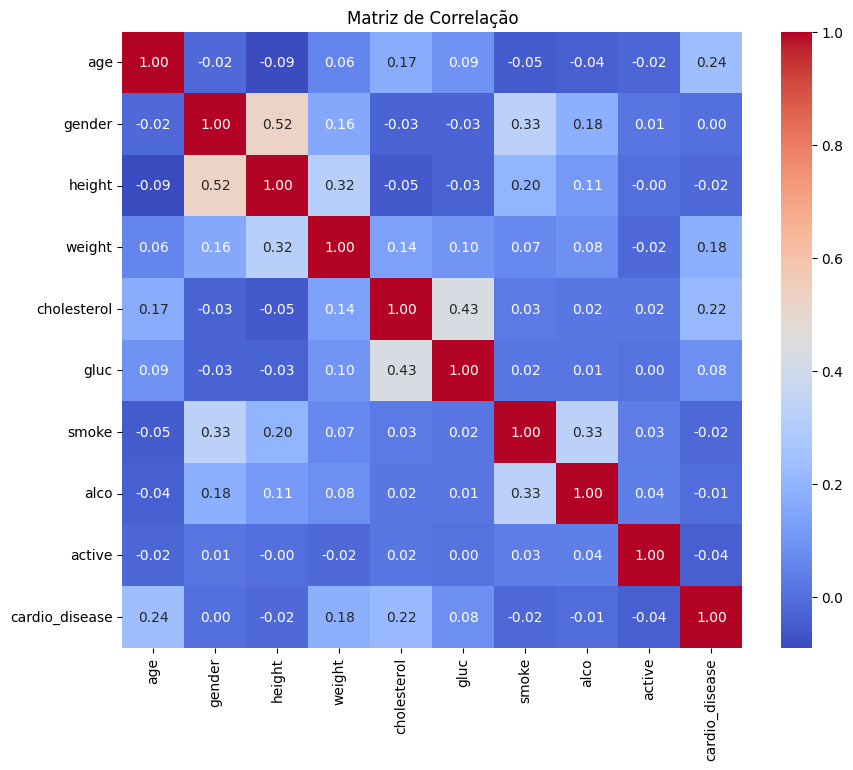

In [240]:
correlation_matrix = base.select_dtypes(include=['number']).corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", annot_kws={"size": 10})
plt.title('Matriz de Correlação')
plt.show()

# 4) Essa é a sua última etapa pré modelo. Você deve:

A) Separar a base em treino e teste.

B) Você considera que essa base precisa que os dados sejam padronizados? Se sim, porque? Se acredita que devem, então realize essa etapa.

C) Verifique se os dados estão balanceados, se não, faça o balanceamento.


D) Visualize as bases de treino, teste (X E Y) e verifique se está tudo adequado.

In [ ]:
# seu código aqui

# 5) Realize a etapa de treinamento do modelo:

A) Faça o treinamento do modelo.

B) Traga o intercept e os coeficientes.

c) Avalie as métricas do modelo treinado

D) Justifique se te parece que o modelo tem feito boas previsões ou não.

In [ ]:
# seu código aqui

# 6) Teste seu modelo!

A) Aplique o modelo aos dados de teste.

B) Avalie as métricas do modelo treinado

C) Plote o gráfico da curva AUC-ROC e explique o que consegue analisar através do gráfico.

In [ ]:
# seu código aqui

# 7) Explique:

A) Explique com suas palavras regressão logistica.

B) Explique porque a regressão logistica é um modelo de classificação.

C) Explique quais pontos em comum a regressão logistica tem da regressão linear.



In [ ]:
# seu código aqui